## Spiral wave contrast

In [17]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 13
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [18]:
path_start = f"/pfs/10/work/hd_cu284-work2/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen"]

titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$"]
paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [19]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

(300, 384)
(300,)


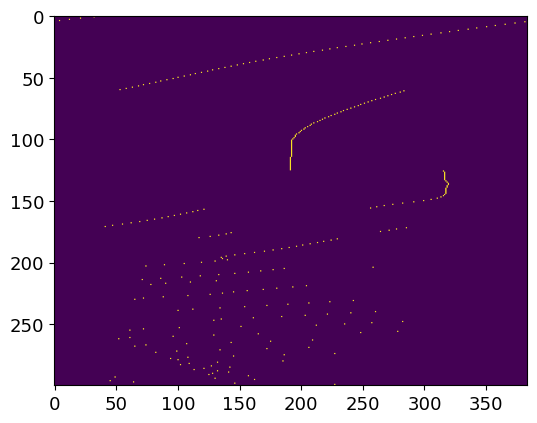

In [20]:
### try marking max
test = rho_cube[0][-1]
print(test.shape)
max_test = np.max(test, axis=1)
print(max_test.shape)
mask = np.zeros(shape = test.shape)
mask[np.arange(test.shape[0]), np.argmax(test, axis=1)] = 1

plt.imshow(mask)

In [21]:
### try marking max
"""
test = rho_cube #  shape: (10, 4, 300, 384)
print(test.shape)
max_test = np.argmax(test, axis=3)
print(max_test.shape)
i_ind = np.arange(max_test.shape[0])[:,None,None]
j_ind =  np.arange(max_test.shape[1])[None,:,None]
rows =  np.arange(max_test.shape[2])[None,None,:]
cols = max_test

print(i_ind.shape, j_ind.shape,rows.shape, cols.shape)

mask = np.zeros(shape = test.shape)
mask[i_ind,j_ind,rows,cols] = 1

plt.imshow(mask[0][-1])
"""

'\ntest = rho_cube #  shape: (10, 4, 300, 384)\nprint(test.shape)\nmax_test = np.argmax(test, axis=3)\nprint(max_test.shape)\ni_ind = np.arange(max_test.shape[0])[:,None,None]\nj_ind =  np.arange(max_test.shape[1])[None,:,None]\nrows =  np.arange(max_test.shape[2])[None,None,:]\ncols = max_test\n\nprint(i_ind.shape, j_ind.shape,rows.shape, cols.shape)\n\nmask = np.zeros(shape = test.shape)\nmask[i_ind,j_ind,rows,cols] = 1\n\nplt.imshow(mask[0][-1])\n'

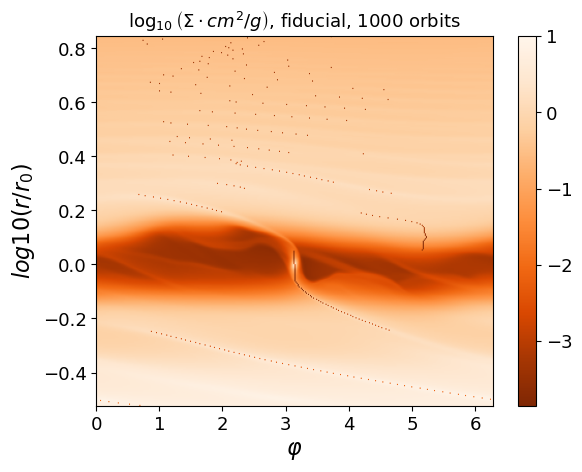

In [24]:
max_cube = np.max(rho_cube, axis=3, keepdims = True)
mask = (max_cube == rho_cube).astype(int)
a=0
#print((max_cube == rho_cube))
#plt.imshow(mask[0][-1],origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
#plt.show()

plt.imshow(np.log10(rho_cube[a][-1])-mask[a][-1]*3, origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
plt.title(f"$\\log_{{10}} \\left(\\Sigma\\cdot cm^2/g\\right)$, {titles[a]}, {(frames[-1])*10} orbits")
plt.colorbar()
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.savefig("img/max_dens_spiral_wave.PNG", bbox_inches="tight")

Finding the maximum isn't good enough. We need some kind of walker or smth.

[114 192]


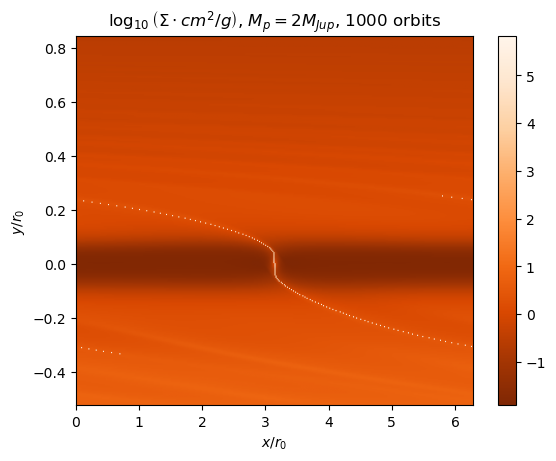

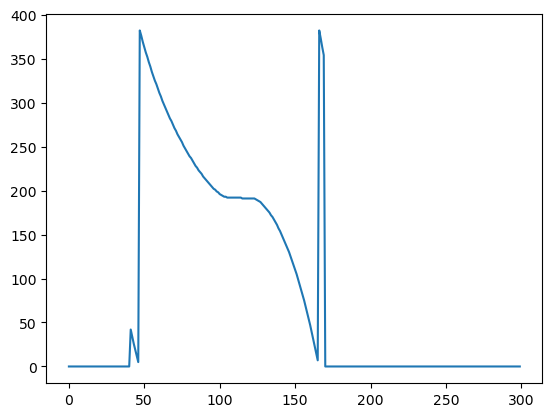

In [167]:
a=2
test = rho_cube[a][-1]
r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
Nphi = 384
phi = np.linspace(0, 2*np.pi, Nphi)

start = np.array([np.interp(1,r_list, np.arange(len(r_list))), len(phi)/2])
start = start.astype(int)
print(start)

walk_pos = [114, 192]

damp = np.ones(len(r_list))*2
lim = 120

"""
for i in range(len(r_list)):
    if i>lim:
        damp[i] = np.exp((-i+lim)/100)
plt.plot(damp)
plt.show()
#"""

# how much the step is pushed to the left
left = 1e-4
walks = np.zeros(len(r_list))
philen = len(phi)*1.0

def sigmoid(x):
    return 1/(1+np.exp(x))


walks[walk_pos[0]] = walk_pos[1]
# walk out

maxr_ind = 170

for i in range(start[0], maxr_ind):#len(r_list)-1):
    dens_strip = np.array(test[i+1])# np.zeros(len(test[i+1]))#
    # make large steps unattractive
    dens_strip += (1+ np.cos((np.arange(len(dens_strip))-walk_pos[1])*np.pi/philen*2))*damp[i]
    # Force walk to the left
    dens_strip += ((np.arange(len(dens_strip))-walk_pos[1]-1)%Nphi)*left

    
    #plt.plot(dens_strip)
    next_pos = np.argmax(dens_strip)
    walks[i] = next_pos
    walk_pos =[i, next_pos]

# walk in
walk_pos = [114, 192]

minr_ind = 40
for i in range(start[0], minr_ind, -1):
    dens_strip = np.array(test[i-1])
    # make large steps unattractive
    dens_strip += (1+ np.cos((np.arange(len(dens_strip))-walk_pos[1])*np.pi/philen*2))*damp[i]
    # force walk to the right
    dens_strip += -((np.arange(len(dens_strip))-walk_pos[1]+1)%Nphi)*left

    
    #plt.plot(dens_strip)
    next_pos = np.argmax(dens_strip)
    walks[i] = next_pos
    walk_pos =[i, next_pos]

# Show the chosen pixels
mask = np.zeros(shape = test.shape)
rlen = len(r_list)
mask[np.arange(rlen).astype(int),walks.astype(int)] = 1

plt.show()
plt.imshow(np.log10(test)+mask*5, origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
plt.title(f"$\\log_{{10}} \\left(\\Sigma\\cdot cm^2/g\\right)$, {titles[a]}, {(frames[-1])*10} orbits")
plt.colorbar()
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.show()

plt.plot(walks)

In [134]:
## Make it a nice function
r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
Nphi = 384
phi = np.linspace(0, 2*np.pi, Nphi)

def find_spirals(data, title=None, damp = np.ones(len(r_list))*2,left = 1e-4,maxr_ind = 175,minr_ind = 40, show_spiral=True, show=True, width=30):
    """
    data: fargo3d surface density.
    damp: how much making small steps is rewarded.
    left: how much going further left is penalized. (Highest penalty for going to the right, because periodicity.)
    maxr_ind: maximum r index to walk to.
    minr_ind: minimum r index to walk to. Necessary because crest finding breaks down at some point.
    width: half width of averaging window for contrast.
    """

    walk_pos = [114, 192]
    walks = np.zeros(len(r_list))
    philen = len(phi)*1.0
    walks[walk_pos[0]] = walk_pos[1]
    # prevent accidentially changing input array by making copy.
    test = np.array(data)
    
    # walk out    
    for i in range(walk_pos[0], maxr_ind):
        dens_strip = np.array(test[i+1])
        # make large steps unattractive
        dens_strip += (1+ np.cos((np.arange(len(dens_strip))-walk_pos[1])*np.pi/philen*2))*damp[i]
        # Force walk to the left
        dens_strip += ((np.arange(len(dens_strip))-walk_pos[1]-1)%Nphi)*left
    
        next_pos = np.argmax(dens_strip)
        walks[i] = next_pos
        walk_pos =[i, next_pos]
    
    # walk in
    walk_pos = [114, 192]
    for i in range(walk_pos[0], minr_ind, -1):
        dens_strip = np.array(test[i-1])
        # make large steps unattractive
        dens_strip += (1+ np.cos((np.arange(len(dens_strip))-walk_pos[1])*np.pi/philen*2))*damp[i]
        # force walk to the right
        dens_strip += -((np.arange(len(dens_strip))-walk_pos[1]+1)%Nphi)*left
        
        next_pos = np.argmax(dens_strip)
        walks[i] = next_pos
        walk_pos =[i, next_pos]

   
    mask = np.zeros(shape = test.shape)
    rlen = len(r_list)
    mask[np.arange(rlen).astype(int),walks.astype(int)] = 1
     # Show the chosen pixels
    if show_spiral:
        plt.imshow(np.log10(test)-mask*5, origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
        plt.title(f"$\\log_{{10}} \\left(\\Sigma\\cdot cm^2/g\\right)$, {title}, {(frames[-1])*10} orbits")
        plt.colorbar()
        plt.ylabel("$log10(r/r_0)$")
        plt.xlabel("$\\varphi$")
        plt.show()

    dens_arr = np.zeros(rlen)*np.nan
    surroundings_arr = np.zeros(rlen)*np.nan
    mask = np.zeros(shape = data.shape)
    width2 = 3
    for i in range(minr_ind, maxr_ind):
        j = int(walks[i])
        if j-width2<0:
            mask[i][:(j+width2)]=1
            mask[i][j-width2:]=1
        elif j+width2>philen:
            mask[i][j-width2:] = 1
            mask[i][:(j+width2-Nphi)] = 1
        else:
            mask[i][(j-width2):(j+width2)]=1
        mask[i] = mask[i] * philen/(width2*2)
    for i in range(minr_ind, maxr_ind):
        dens_arr[i] = np.mean(data[i]*mask[i])

    mask = np.zeros(shape = data.shape)
   
    for i in range(minr_ind, maxr_ind):
        j = int(walks[i])
        if j-width<0:
            mask[i][:(j+width)]=1
            mask[i][j-width:]=1
        elif j+width>philen:
            mask[i][j-width:] = 1
            mask[i][:(j+width-Nphi)] = 1
        else:
            mask[i][(j-width):(j+width)]=1
        mask[i] = mask[i] * philen/(width*2)
        
        surroundings_arr[i] = np.mean(data[i]*mask[i])

    local_contrast = dens_arr/surroundings_arr
    if show:
        plt.plot(r_list,dens_arr)
        plt.xlabel("$r/r_0$")
        plt.ylabel("$\\Sigma_{crest}$ [g/cm²]")
        plt.title("Surface density at wave crest")
        plt.yscale("log")
        plt.show()

        
        rho_mean = np.mean(data, axis=1)
        plt.plot(r_list,dens_arr/rho_mean, label="global average")
        plt.plot(r_list,dens_arr/surroundings_arr, label="local average")
        plt.plot([r_list[minr_ind], r_list[maxr_ind]], [1,1], linestyle="--", color="grey")
        plt.xlabel("$r/r_0$")
        plt.title("Wave contrast")
        plt.ylabel("$\\Sigma_{crest}/\\Sigma_{avg}$")
        plt.yscale("log")
        plt.legend()
        plt.show()
        
        

    return walks, mask, dens_arr, local_contrast


In [135]:
r_list[40]

np.float64(0.4565813411230336)

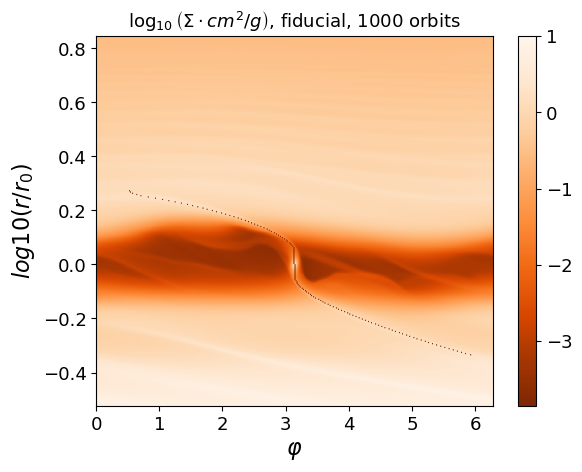

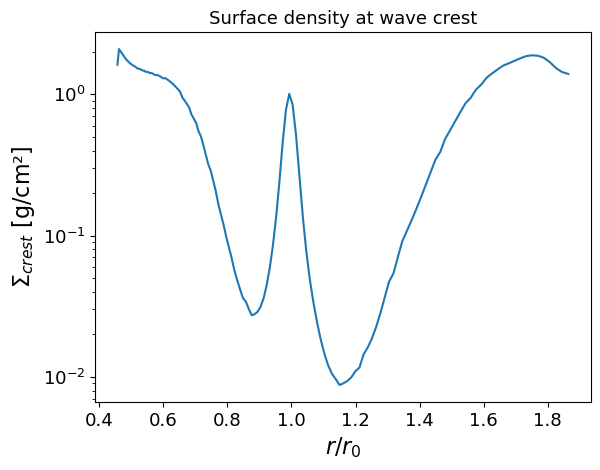

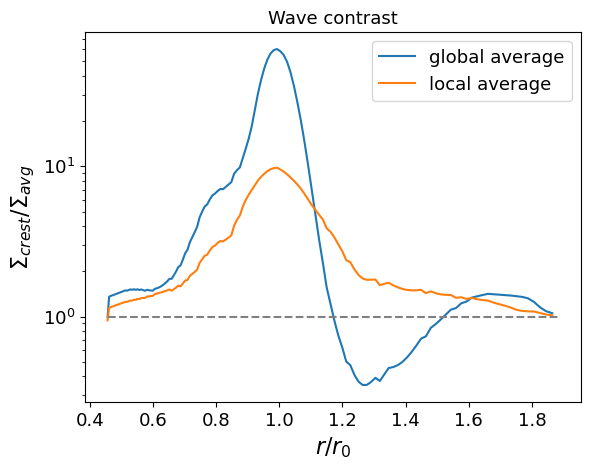

144.0


In [136]:
a=0
walks, mask, dens_arr, local_contrast= find_spirals(rho_cube[a][-1], show=True, title=titles[a])
#plt.savefig("img/walker_spiral_wave.PNG", bbox_inches="tight")
print(walks[150])

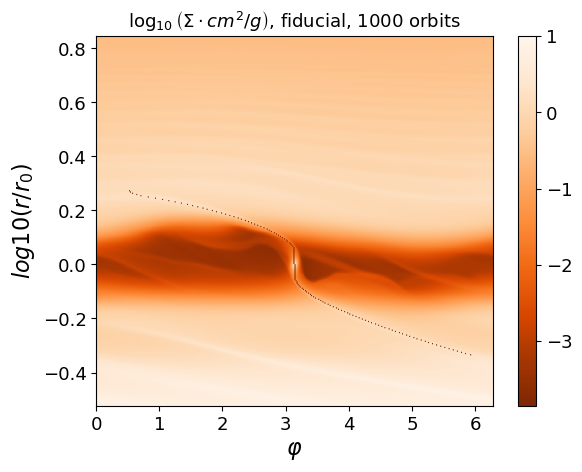

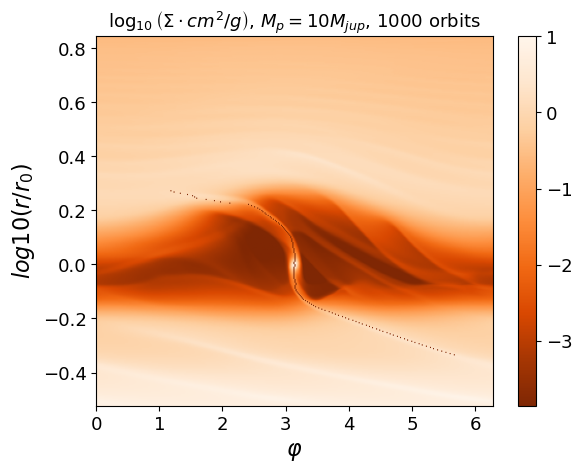

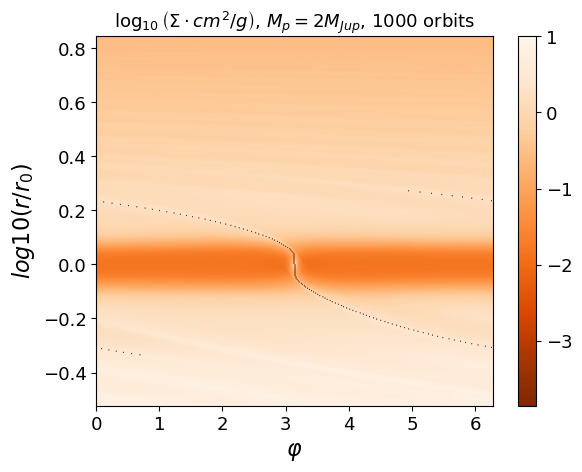

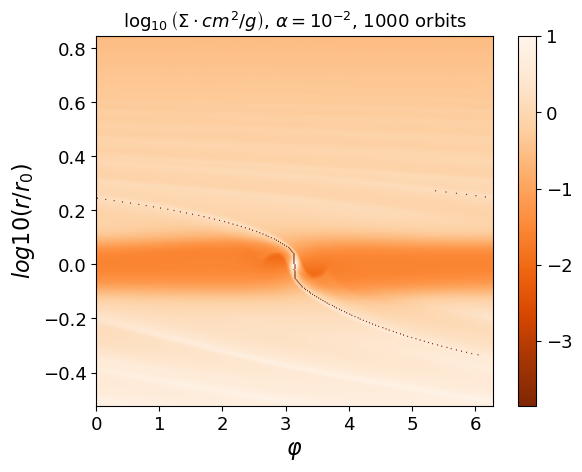

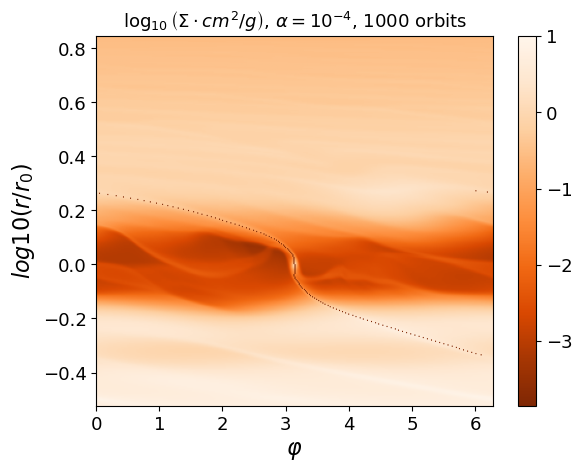

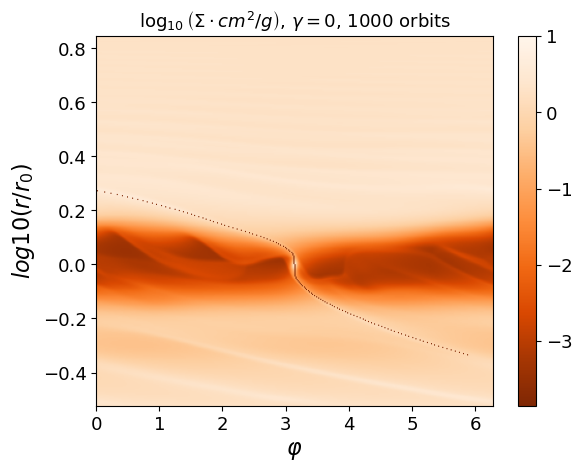

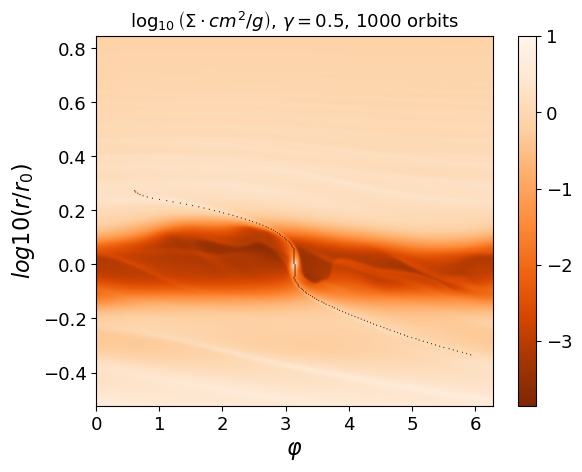

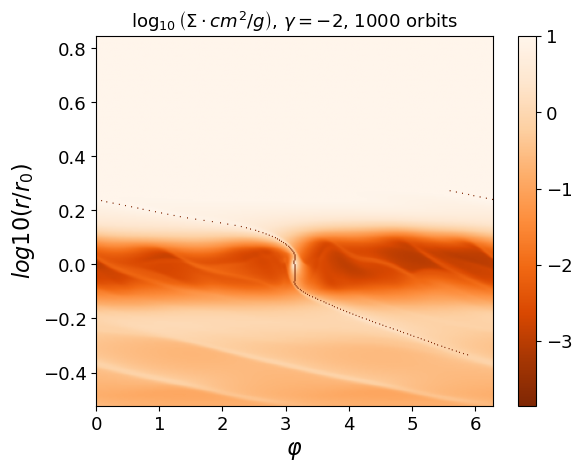

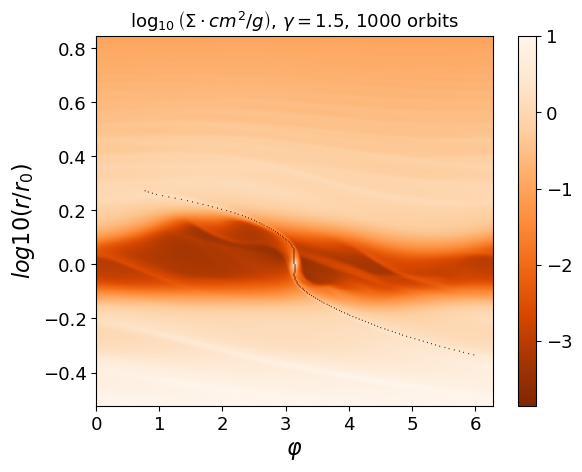

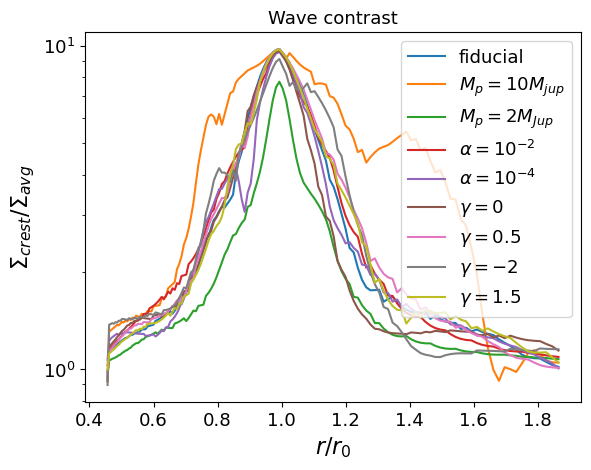

In [81]:
local_contrast_cube = []
for i in range(len(rho_cube)):
    walk_pos, mask, dens_arr, local_contrast= find_spirals(rho_cube[i][-1], show=False,title=titles[i]) #show_spiral=False)
    local_contrast_cube.append(local_contrast)

for i in range(len(rho_cube)):
    plt.plot(r_list,local_contrast_cube[i], label=titles[i])

plt.xlabel("$r/r_0$")
plt.title("Wave contrast")
plt.ylabel("$\\Sigma_{crest}/\\Sigma_{avg}$")
plt.yscale("log")
plt.legend()
plt.show()

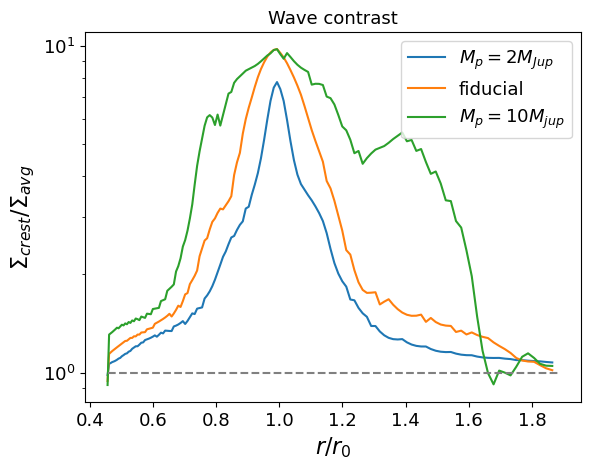

In [86]:
maxr_ind = 175
minr_ind = 40
index_for_mass=[2,0,1]
for it,i in enumerate(index_for_mass):
    plt.plot(r_list,local_contrast_cube[i], label=titles[i])

plt.plot([r_list[minr_ind], r_list[maxr_ind]], [1,1], linestyle="--", color="grey")

plt.xlabel("$r/r_0$")
plt.title("Wave contrast")
plt.ylabel("$\\Sigma_{crest}/\\Sigma_{avg}$")
plt.yscale("log")

plt.legend()
plt.savefig("img/wave_contrast_mass.PNG", bbox_inches="tight")

plt.show()

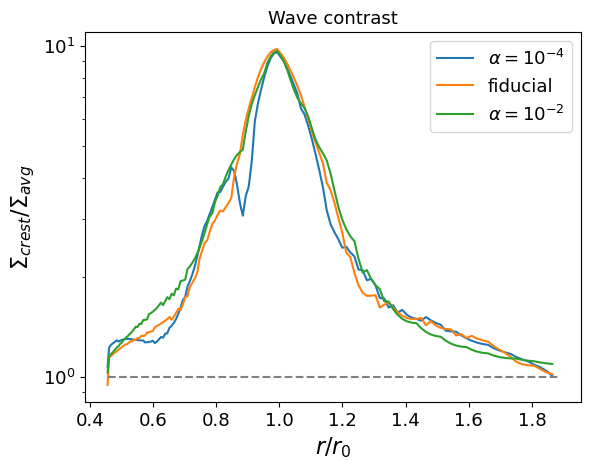

In [87]:

index_for_visc=[4,0,3]
for it,i in enumerate(index_for_visc):
    plt.plot(r_list,local_contrast_cube[i], label=titles[i])

plt.plot([r_list[minr_ind], r_list[maxr_ind]], [1,1], linestyle="--", color="grey")

plt.xlabel("$r/r_0$")
plt.title("Wave contrast")
plt.ylabel("$\\Sigma_{crest}/\\Sigma_{avg}$")
plt.yscale("log")
plt.legend()
plt.savefig("img/wave_contrast_alpha.PNG", bbox_inches="tight")

plt.show()

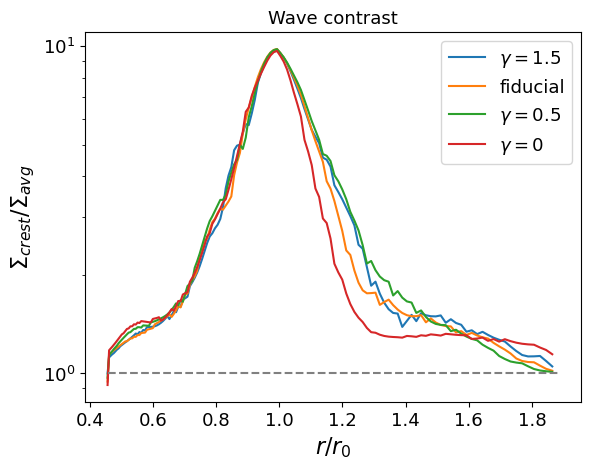

In [88]:
index_for_sigslop = [8,0,6,5]
for it,i in enumerate(index_for_sigslop):
    plt.plot(r_list,local_contrast_cube[i], label=titles[i])

plt.plot([r_list[minr_ind], r_list[maxr_ind]], [1,1], linestyle="--", color="grey")

plt.xlabel("$r/r_0$")
plt.title("Wave contrast")
plt.ylabel("$\\Sigma_{crest}/\\Sigma_{avg}$")
plt.yscale("log")
plt.legend()
plt.savefig("img/wave_contrast_gamma.PNG", bbox_inches="tight")

plt.show()

In [89]:
6/384 *360

5.625

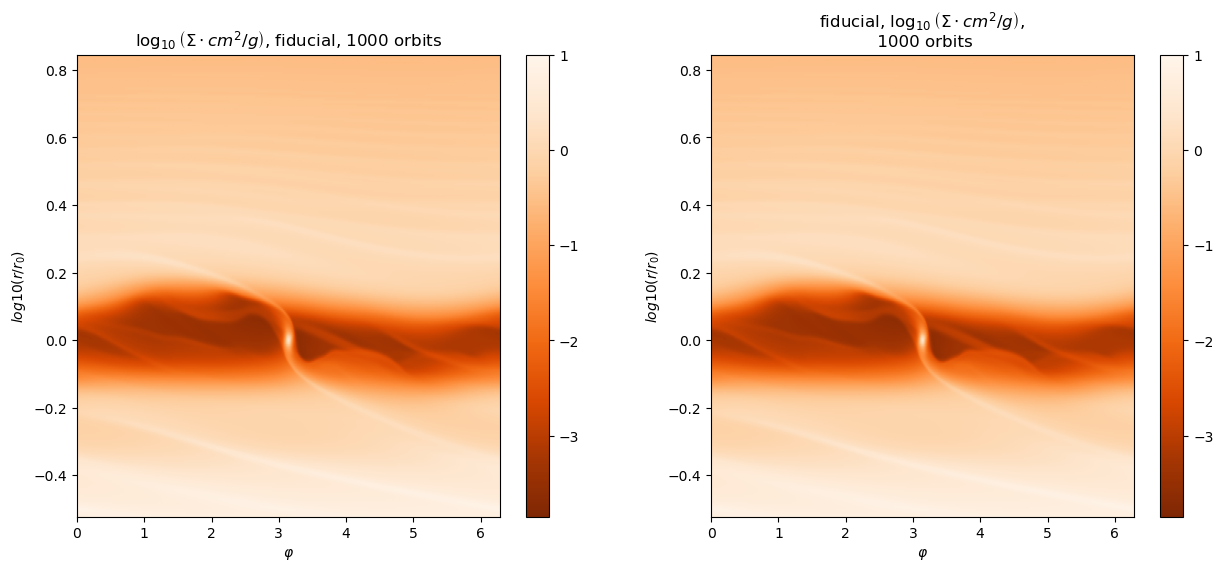

In [10]:
## make this a round plot so I know what's going on.
title=titles[0]
frame = frames[-1]

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(np.log10(rho_cube[0][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
plt.title(f"$\\log_{{10}} \\left(\\Sigma\\cdot cm^2/g\\right)$, {title}, {(frames[-1])*10} orbits")
plt.colorbar()
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
#plt.axis("scaled")

plt.subplot(1,2,2)

plt.imshow(np.log10(rho_cube[0][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
plt.title(f"{title}, $\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, \n {(frame)*10} orbits")
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.colorbar()
#plt.axis("scaled")

#plt.savefig("img/fargo_cartesian_fiducial.PNG")

384


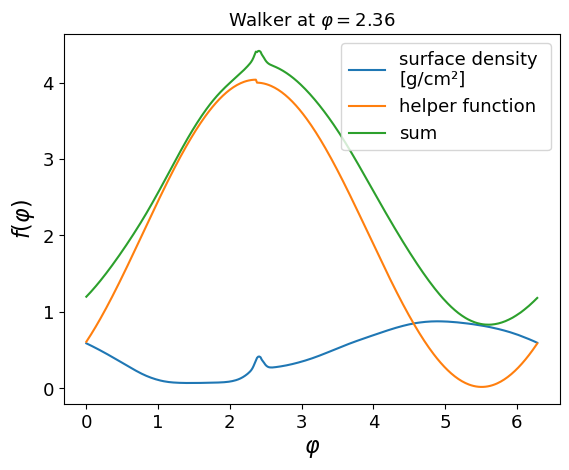

In [148]:
damp = 2
left=1e-4
walk_pos = [150,144]

print(Nphi)
dens_strip = np.zeros(Nphi)
philen=Nphi*1.0
dens_strip = np.array(rho_cube[0][-1][walk_pos[0]])
plt.plot(phi,dens_strip, label="surface density \n[g/cm²]")

dens_strip += (1+ np.cos((np.arange(len(dens_strip))-walk_pos[1])*np.pi/philen*2))*damp
# Force walk to the left
dens_strip += ((np.arange(len(dens_strip))-walk_pos[1]-1)%Nphi)*left

new = np.zeros(Nphi)

new += (1+ np.cos((np.arange(len(dens_strip))-walk_pos[1])*np.pi/philen*2))*damp
# Force walk to the left
new += ((np.arange(len(dens_strip))-walk_pos[1]-1)%Nphi)*left
plt.plot(phi,new, label="helper function")
plt.plot(phi,dens_strip, label="sum")

plt.xlabel("$\\varphi$")
plt.ylabel("$f(\\varphi)$")
plt.legend()
plt.title(f"Walker at $\\varphi=${round(phi[walk_pos[1]],2)}")
plt.savefig("img/mystery_func.PNG", bbox_inches="tight")

In [ ]:
test = np.arange(10)

for i in range(10):
    if i-2<0:
        print(test[:(i+2)], test[i-2:])
    elif i+2>10:
        print(test[i-2:], test[:i+2-10])
    else:
        print(test[(i-2):(i+2)])